In [1]:
#Importing Libraries 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
import ast 
from datasets import load_dataset  

#loading Data 
dataset = load_dataset('lukebarousse/data_jobs') 
df = dataset['train'].to_pandas() 

#Data Cleanup 
df['job_posted_date'] = pd.to_datetime(df['job_posted_date']) 
df['job_skills'] = df['job_skills'].apply(lambda x : ast.literal_eval(x) if pd.notna(x) else x)


c:\Users\agarw\Desktop\Python Project\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
df_US = df[df['job_country']=='United States']

In [4]:
df_skills = df_US.explode('job_skills')

In [12]:
df_skills_count = df_skills.groupby(['job_skills','job_title_short']).size() 
df_skills_count = df_skills_count.reset_index(name='skill_count')  
df_skills_count.sort_values(by='skill_count',ascending=False,inplace=True) 


In [13]:
job_titles = df_skills_count['job_title_short'].unique().tolist() 

job_titles = sorted(job_titles[:3]) 

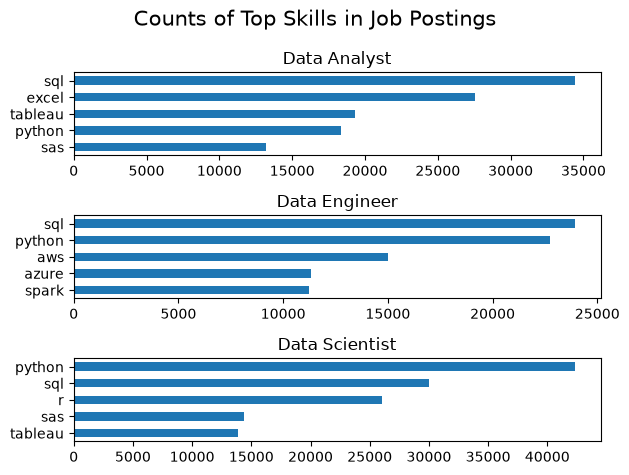

In [18]:
fig ,ax = plt.subplots(len(job_titles),1) 

for i,job_title in enumerate(job_titles): 
    df_plot = df_skills_count[df_skills_count['job_title_short']==job_title].head(5) 
    df_plot.plot(kind='barh',x='job_skills',y='skill_count',ax=ax[i],title =job_title) 
    ax[i].invert_yaxis() 
    ax[i].set_ylabel('') 
    ax[i].legend().set_visible(False) 

fig.suptitle('Counts of Top Skills in Job Postings',fontsize=15)  
fig.tight_layout()
plt.show()

In [20]:
df_job_title_count = df_US['job_title_short'].value_counts().reset_index(name='jobs_total')

In [21]:
df_skills_perc = pd.merge(df_skills_count,df_job_title_count,how='left',on='job_title_short')

In [26]:
df_skills_perc['skill_percent'] = 100 * df_skills_perc['skill_count']/df_skills_perc['jobs_total'] 

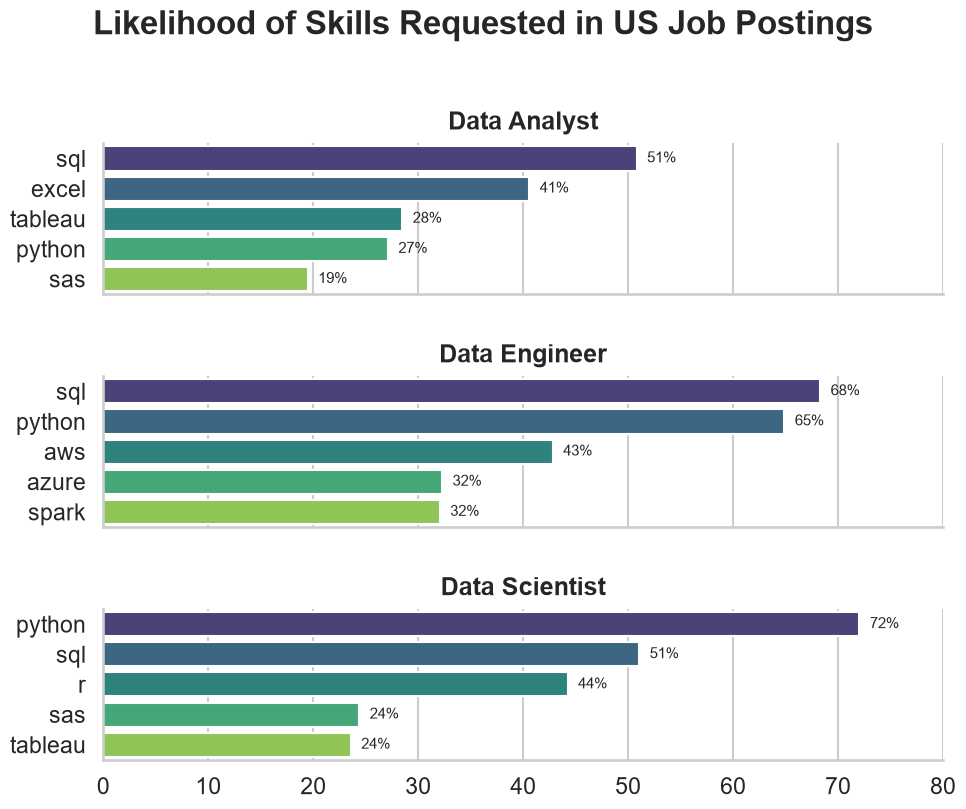

In [39]:
# Theme
sns.set_theme(style='whitegrid', context='talk')

# Figure
fig, ax = plt.subplots(
    len(job_titles),
    1,
    figsize=(10, 8),
    sharex=True
)

# Color palette
palette = sns.color_palette('viridis', 5)

for i, job_title in enumerate(job_titles):

    # Top 5 skills
    df_plot = (
        df_skills_perc[
            df_skills_perc['job_title_short'] == job_title
        ]
        .head(5)
    )

    # Barplot
    sns.barplot(
        data=df_plot,
        x='skill_percent',
        y='job_skills',
        hue='job_skills',
        palette=palette,
        dodge=False,
        legend=False,
        ax=ax[i]
    )

    # Titles
    ax[i].set_title(
        job_title,
        fontsize=18,
        weight='bold',
        pad=10
    )

    # Axis labels
    ax[i].set_xlabel('')
    ax[i].set_ylabel('')

    # Limits
    ax[i].set_xlim(0, 80)

    # Add labels
    for n, v in enumerate(df_plot['skill_percent']):
        ax[i].text(
            v + 1,
            n,
            f'{v:.0f}%',
            va='center',
            fontsize=11
        )

    # Remove unnecessary ticks
    if i != len(job_titles)-1:
        ax[i].tick_params(axis='x', labelbottom=False)

    # Clean spines
    sns.despine(ax=ax[i], left=False, bottom=False)


ax[-1].tick_params(axis='x', labelbottom=True)
# Main title
fig.suptitle(
    'Likelihood of Skills Requested in US Job Postings',
    fontsize=24,
    weight='bold',
    y=1.02
)

# Layout
fig.tight_layout(h_pad=2)

plt.show()